In [6]:
import numpy as np
import matplotlib.pyplot as plt
from function_library_OOP import DetectorSetup

In [7]:
directory: str = "Transverse_ImpactParameter_Plots"

rescaling_factor = 10**6   # 10^6 µm = 1 m

plt.rcParams["figure.figsize"] = (5,5)
xlabel = r"$p_{T}$ [GeV/c]"
ylabel = r"$\sigma_{r \phi}$ [$\mu m$]"

### Global variables and detector initialization

In [8]:
spatial_resolution_ITS3 = 5 * 10**-6	
average_layer_radii_ITS3 = np.array([19, 25.2, 31.5, 196, 245, 344, 393]) * 10**-3            # average radius of ITS3 layers in meters
layerthickness_ITS3 = [0.0007, 0.0007, 0.0007, 0.0110, 0.0110, 0.0110, 0.0110]                # thickness of the detector planes in units of radiation length 
detector_resolutions_rphi_ITS3 = [spatial_resolution_ITS3 for i in range(7)]                  # spatial resolution of the ITS3 layers in rphi in meters
detector_resolutions_z_ITS3 = [spatial_resolution_ITS3 for i in range(7)]                     # spatial resolution of the ITS3  layers in z    in meters
radiation_length_air_ITS3: float = 303.9                                                      # radiation length of air in meters
magnetic_field_strength_ITS3: float = 0.5                                                     # strength of magnetic field in Alice in Tesla

ITS3 = DetectorSetup(average_layer_radii_ITS3, layerthickness_ITS3, detector_resolutions_rphi_ITS3, detector_resolutions_z_ITS3, radiation_length_air_ITS3, magnetic_field_strength_ITS3)

Detector Setup initialized


In [9]:
proton_momenta = np.arange(0.2, 4, 0.1)                     # momentum of particle in GeV/c
proton_mass = 1                                             # mass of particle in GeV/c^2 
pion_momenta = np.arange(0.1, 1.1, 0.02)                       # momentum of particle in GeV/c
pion_mass = 0.150                                           # mass of particle in GeV/c^2

N = 7                                                       # Number of layers with hits 
extrapolation_radius = 0.01                 # extrapolation length in meters (is defined away from layers with hits / away from the IU layer) ;
theta = 90                                 # polar angles of the particle (test case = 90°, 67.5°, 45°)

proton_rphi = np.array([ITS3.transverse_track_position_uncertainty(momentum, proton_mass, N, extrapolation_radius, theta) for momentum in proton_momenta])
pion_rphi = np.array([ITS3.transverse_track_position_uncertainty(momentum, pion_mass, N, extrapolation_radius, theta) for momentum in pion_momenta])

proton_z = np.array([ITS3.longitudinal_track_position_uncertainty(momentum, proton_mass, N, extrapolation_radius, theta) for momentum in proton_momenta])
pion_z = np.array([ITS3.longitudinal_track_position_uncertainty(momentum, pion_mass, N, extrapolation_radius, theta) for momentum in pion_momenta])

proton_pT = np.array([ITS3.transverse_momentum_reso(momentum, proton_mass, N, theta) for momentum in proton_momenta])
pion_pT = np.array([ITS3.transverse_momentum_reso(momentum, pion_mass, N, theta) for momentum in pion_momenta])

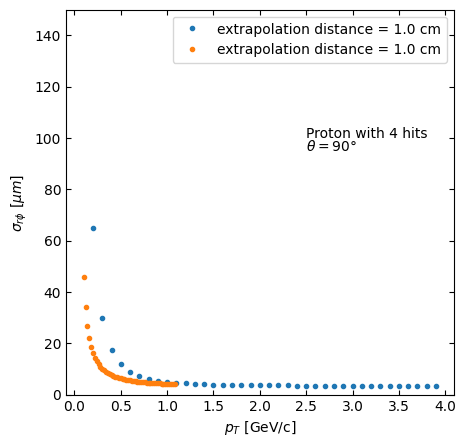

In [10]:
plt.plot(proton_momenta, proton_rphi*rescaling_factor, ".", label=f"extrapolation distance = {extrapolation_radius*100} cm")
plt.plot(pion_momenta, pion_rphi*rescaling_factor, ".", label=f"extrapolation distance = {extrapolation_radius*100} cm")
plt.legend()
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.ylim(0, 150)
plt.text(2.5, 100, "Proton with 4 hits")
plt.text(2.5, 95, fr"$\theta = {theta}$°")
plt.tick_params(top=True, right=True, direction="in")